In [9]:

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
def _solve_homography(src_xy, dst_xy):
    # src_xy, dst_xy: [4, 2]
    src_xy = tf.cast(src_xy, tf.float32)
    dst_xy = tf.cast(dst_xy, tf.float32)

    src_xy = tf.ensure_shape(src_xy, [4, 2])
    dst_xy = tf.ensure_shape(dst_xy, [4, 2])

    x = src_xy[:, 0]
    y = src_xy[:, 1]
    u = dst_xy[:, 0]
    v = dst_xy[:, 1]

    zeros = tf.zeros_like(x)
    ones = tf.ones_like(x)

    a1 = tf.stack([x, y, ones, zeros, zeros, zeros, -u * x, -u * y], axis=1)
    a2 = tf.stack([zeros, zeros, zeros, x, y, ones, -v * x, -v * y], axis=1)

    A = tf.reshape(tf.stack([a1, a2], axis=1), [8, 8])
    b = tf.reshape(tf.stack([u, v], axis=1), [8, 1])

    h = tf.linalg.solve(A, b)[:, 0]
    H = tf.reshape(
        tf.stack([
            h[0], h[1], h[2],
            h[3], h[4], h[5],
            h[6], h[7], 1.0
        ]),
        [3, 3]
    )
    return H


def _projective_transform_from_corners(src_xy, dst_xy):
    # ImageProjectiveTransformV3 expects output->input mapping
    H_src_to_dst = _solve_homography(src_xy, dst_xy)
    H_dst_to_src = tf.linalg.inv(H_src_to_dst)
    H_dst_to_src = H_dst_to_src / H_dst_to_src[2, 2]

    return tf.stack([
        H_dst_to_src[0, 0], H_dst_to_src[0, 1], H_dst_to_src[0, 2],
        H_dst_to_src[1, 0], H_dst_to_src[1, 1], H_dst_to_src[1, 2],
        H_dst_to_src[2, 0], H_dst_to_src[2, 1]
    ])


def _warp_image_with_corners(image, dst_xy, fill_value=255.0):
    image = tf.cast(image, tf.float32)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    src_xy = tf.cast([
        [0.0, 0.0],
        [tf.cast(w - 1, tf.float32), 0.0],
        [tf.cast(w - 1, tf.float32), tf.cast(h - 1, tf.float32)],
        [0.0, tf.cast(h - 1, tf.float32)],
    ], tf.float32)

    transform = _projective_transform_from_corners(src_xy, dst_xy)[None, :]

    warped = tf.raw_ops.ImageProjectiveTransformV3(
        images=image[None, ...],
        transforms=transform,
        output_shape=tf.stack([h, w]),
        interpolation="BILINEAR",
        fill_mode="CONSTANT",
        fill_value=tf.cast(fill_value, tf.float32),
    )
    return warped[0]


class RandomBrightness255(layers.Layer):
    # max_delta is a fraction of 255, e.g. 0.10 => +/-25.5 intensity
    def __init__(self, max_delta=0.12, **kwargs):
        super().__init__(**kwargs)
        self.max_delta = float(max_delta)

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x
        delta = tf.random.uniform([], -self.max_delta, self.max_delta) * 255.0
        return x + delta

    def compute_output_shape(self, input_shape):
        return input_shape


class AddGaussianNoise255(layers.Layer):
    # stddev is in pixel units for images in [0, 255]
    def __init__(self, stddev=3.0, **kwargs):
        super().__init__(**kwargs)
        self.stddev = float(stddev)

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x
        noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=self.stddev, dtype=tf.float32)
        return x + noise

    def compute_output_shape(self, input_shape):
        return input_shape


class RandomGamma(layers.Layer):
    # Camera-like exposure / auto-adjust changes
    def __init__(self, gamma_range=(0.85, 1.20), gain_range=(0.95, 1.05), **kwargs):
        super().__init__(**kwargs)
        self.gamma_range = gamma_range
        self.gain_range = gain_range

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x

        gamma = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
        gain = tf.random.uniform([], self.gain_range[0], self.gain_range[1])

        x01 = tf.clip_by_value(x / 255.0, 0.0, 1.0)
        x01 = tf.image.adjust_gamma(x01, gamma=gamma, gain=gain)
        return x01 * 255.0

    def compute_output_shape(self, input_shape):
        return input_shape


class RandomWebcamTablePerspective(layers.Layer):
    """
    Realistic projective augmentation for a camera looking at an object on a table.
    Main effect:
      - downward tilt around X axis (~30°)
      - small left/right yaw
      - small in-plane roll
      - small zoom / translation
    """

    def __init__(
        self,
        p=0.90,
        tilt_range_deg=(22.0, 35.0),
        yaw_range_deg=(-10.0, 10.0),
        roll_range_deg=(-5.0, 5.0),
        zoom_range=(0.92, 1.08),
        shift_range=0.08,
        camera_distance_range=(2.6, 3.6),
        fill_value=255.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.p = float(p)
        self.tilt_range_deg = tilt_range_deg
        self.yaw_range_deg = yaw_range_deg
        self.roll_range_deg = roll_range_deg
        self.zoom_range = zoom_range
        self.shift_range = float(shift_range)
        self.camera_distance_range = camera_distance_range
        self.fill_value = float(fill_value)

    @staticmethod
    def _deg2rad(x):
        return x * (tf.constant(3.141592653589793, tf.float32) / 180.0)

    def _make_rotation(self, tilt_deg, yaw_deg, roll_deg):
        ax = self._deg2rad(tilt_deg)
        ay = self._deg2rad(yaw_deg)
        az = self._deg2rad(roll_deg)

        cx, sx = tf.cos(ax), tf.sin(ax)
        cy, sy = tf.cos(ay), tf.sin(ay)
        cz, sz = tf.cos(az), tf.sin(az)

        Rx = tf.stack([
            [1.0, 0.0, 0.0],
            [0.0, cx, -sx],
            [0.0, sx, cx],
        ])

        Ry = tf.stack([
            [cy, 0.0, sy],
            [0.0, 1.0, 0.0],
            [-sy, 0.0, cy],
        ])

        Rz = tf.stack([
            [cz, -sz, 0.0],
            [sz, cz, 0.0],
            [0.0, 0.0, 1.0],
        ])

        return Rz @ Ry @ Rx

    def _augment_impl(self, image):
        image = tf.cast(image, tf.float32)
        h = tf.cast(tf.shape(image)[0], tf.float32)
        w = tf.cast(tf.shape(image)[1], tf.float32)

        tilt = tf.random.uniform([], self.tilt_range_deg[0], self.tilt_range_deg[1])
        yaw = tf.random.uniform([], self.yaw_range_deg[0], self.yaw_range_deg[1])
        roll = tf.random.uniform([], self.roll_range_deg[0], self.roll_range_deg[1])
        zoom = tf.random.uniform([], self.zoom_range[0], self.zoom_range[1])
        tx = tf.random.uniform([], -self.shift_range, self.shift_range)
        ty = tf.random.uniform([], -self.shift_range, self.shift_range)
        cam_dist = tf.random.uniform([], self.camera_distance_range[0], self.camera_distance_range[1])

        corners_3d = tf.constant([
            [-1.0, -1.0, 0.0],
            [ 1.0, -1.0, 0.0],
            [ 1.0,  1.0, 0.0],
            [-1.0,  1.0, 0.0],
        ], dtype=tf.float32)

        R = self._make_rotation(tilt, yaw, roll)
        rotated = tf.transpose(R @ tf.transpose(corners_3d))

        z = rotated[:, 2] + cam_dist
        xy = rotated[:, :2] / z[:, None]

        xy_centered = xy - tf.reduce_mean(xy, axis=0, keepdims=True)
        max_abs = tf.reduce_max(tf.abs(xy_centered)) + 1e-6
        xy_norm = xy_centered / (2.0 * max_abs) + 0.5

        xy_norm = (xy_norm - 0.5) * zoom + tf.constant([0.5, 0.5], dtype=tf.float32)
        xy_norm = xy_norm + tf.stack([tx, ty])[None, :]
        xy_norm = tf.clip_by_value(xy_norm, 0.02, 0.98)

        dst_xy = xy_norm * tf.stack([w - 1.0, h - 1.0])[None, :]
        return _warp_image_with_corners(image, dst_xy, fill_value=self.fill_value)

    def _augment_one(self, image):
        apply_aug = tf.random.uniform([]) < self.p
        return tf.cond(
            apply_aug,
            lambda: self._augment_impl(image),
            lambda: tf.cast(image, tf.float32)
        )

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x

        image_spec = tf.TensorSpec(
            shape=(x.shape[1], x.shape[2], x.shape[3]),
            dtype=tf.float32
        )

        y = tf.map_fn(
            self._augment_one,
            x,
            fn_output_signature=image_spec
        )

        y = tf.ensure_shape(y, x.shape)
        return y

    def compute_output_shape(self, input_shape):
        return input_shape


data_augmentation = keras.Sequential([
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=0.04, fill_mode="constant", fill_value=255.0),
    layers.RandomTranslation(height_factor=0.04, width_factor=0.04, fill_mode="constant", fill_value=255.0),
    layers.RandomZoom(height_factor=(-0.08, 0.06), width_factor=(-0.08, 0.06), fill_mode="constant", fill_value=255.0),

    RandomWebcamTablePerspective(
        p=0.95,
        # tilt_range_deg=(10.0, 18.0)   # weak perspective
        # tilt_range_deg=(25.0, 35.0)   # good realistic ~30° webcam view
        tilt_range_deg=(35.0, 50.0),   # very strong perspective
        # yaw_range_deg=(-8.0, 8.0),
        # yaw_range_deg=(-3.0, 3.0)    # almost straight
        # yaw_range_deg=(-8.0, 8.0)    # realistic small side variation
        yaw_range_deg=(-15.0, 15.0),  # stronger left/right skew

        roll_range_deg=(-4.0, 4.0),
        zoom_range=(0.95, 1.08),
        shift_range=0.06,
        camera_distance_range=(2.2, 2.8),   # stronger perspective
       # camera_distance_range=(2.8, 3.4),   # balanced realistic
       # camera_distance_range=(4.0, 5.0),   # flatter view

        fill_value=255.0,
    ),

    RandomBrightness255(max_delta=0.10),
    layers.RandomContrast(factor=0.15),
    RandomGamma(gamma_range=(0.90, 1.15), gain_range=(0.97, 1.03)),
    AddGaussianNoise255(stddev=2.5),
], name="coin_webcam_augmentation")

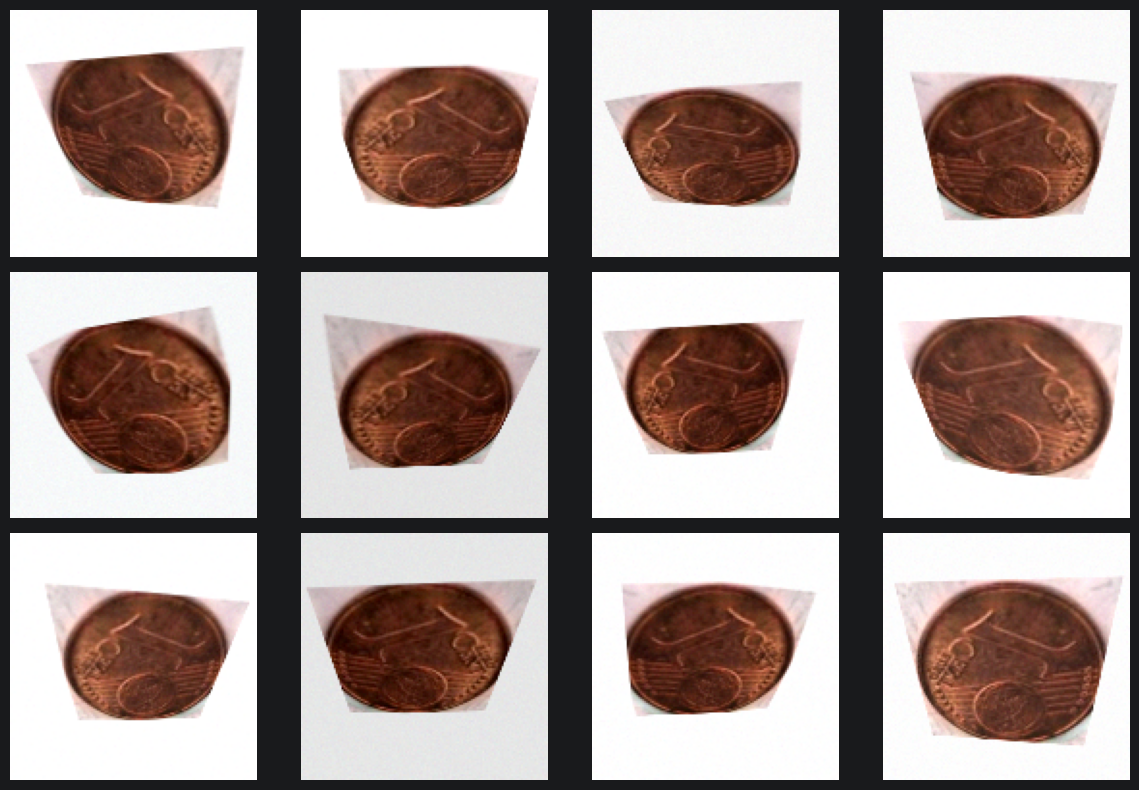

In [11]:
img_path = "../../data/coin_tf_dataset/0/1.jpg"
img = tf.keras.utils.load_img(img_path, target_size=(128, 128))
img = tf.keras.utils.img_to_array(img)
img = tf.expand_dims(img, axis=0)

plt.figure(figsize=(12, 8))
for i in range(12):
    aug = data_augmentation(img, training=True)[0]
    aug = tf.clip_by_value(aug, 0.0, 255.0)
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(aug, tf.uint8))
    plt.axis("off")

plt.tight_layout()
plt.show()